# 08c · GSE65391 · RNA_array · pvclust-py: which gene clusters are supported? (Python)

Reads `hub_matrix_first_visits.csv` and `hub_genes.csv` (written by notebook 07). Writes
`pvclust_genes.pkl` in `data/run_artifacts/GSE65391/` and the dendrogram to `figures/GSE65391/`.

**Method.** Hierarchical clustering with approximately unbiased (AU) p-values from multiscale bootstrap
resampling (Suzuki R, Shimodaira H. Pvclust: an R package for assessing the uncertainty in hierarchical
clustering. *Bioinformatics* 2006;22:1540-1542, doi:10.1093/bioinformatics/btl117; multiscale bootstrap:
Shimodaira H. An approximately unbiased test of phylogenetic tree selection. *Syst Biol* 2002;51:492-508,
doi:10.1080/10635150290069913). A cluster with AU >= 0.95 is supported at the 5% level: it would reappear
if another sample of patients were drawn from the same population.

**Implementation.** pvclust-py (NIH-NLM/pvclust-py, pinned in `endotypes-transcriptomics.yml` to commit
6b0c3bf), a line-by-line Python port of R pvclust 2.2-0 checked against R fixtures.

| setting | value | reason |
|---|---|---|
| objects clustered | the 140 hub genes | this notebook asks about gene groups |
| resampling units | the 157 patients (first visits) | pvclust-py documentation: resampling samples to cluster analytes is "the sound direction" |
| distance | `minkowski` (p = 2, Euclidean) | as in the R heatmaps; pvclust's minkowski is always p = 2 |
| linkage | `ward.D2` | as in the R heatmaps |
| bootstrap replicates | 1,000 per scale | R pvclust's default |
| scales r | 0.5 to 1.4 by 0.1 | R pvclust's default |
| seed | 20260928 | the project seed |

**No k.** The tree is not cut at a number of groups. `pvpick` (alpha = 0.95, largest non-overlapping
clusters first) returns the clusters that clear the AU threshold.

**Test.** Each significant gene cluster against the WGCNA modules: does it hold the hub genes of one
module, or mix modules?

## Load the matrix written by notebook 07

In [1]:
import pickle, collections
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
from pvclust_py.core import pvclust, pvpick
from pvclust_py.plot import dendrogram

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "endotypes-transcriptomics.yml").exists())
ART  = ROOT / "data" / "run_artifacts" / "GSE65391"
FIG  = ROOT / "figures" / "GSE65391"; FIG.mkdir(parents=True, exist_ok=True)
SEED = 20260928
pd.set_option("display.max_colwidth", None)   # show every cluster member

X     = pd.read_csv(ART / "hub_matrix_first_visits.csv", index_col=0)     # patients x genes
genes = pd.read_csv(ART / "hub_genes.csv").set_index("gene")["module"]
X.shape

(157, 140)

**Explanation**
- This notebook runs in Python, because pvclust-py is a Python package.
- `import` loads Python modules: `pickle` saves Python objects to a file; `collections` provides `Counter`,
  which counts items; `pathlib.Path` handles file paths; `pandas` (as `pd`) reads and shows tables;
  `IPython.display` shows a saved image in the notebook.
- `pandas` holds tables in Python (McKinney W. Data structures for statistical computing in Python.
  *Proceedings of the 9th Python in Science Conference* 2010:56-61).
- `from pvclust_py.core import pvclust, pvpick` loads the two functions used below.
- `ROOT = next(...)`: the Python version of `.find_root()` in `src/paths.R` (see notebook 00). It moves up
  from the current folder to the first one that contains `endotypes-transcriptomics.yml`.
- `ART` and `FIG` are the Python versions of `art()` and `fig()` for this study. `/` joins parts of a path.
- `FIG.mkdir(parents=True, exist_ok=True)` creates the figure folder if it does not exist.
- `pd.set_option("display.max_colwidth", None)` shows long text in tables in full.
- `pd.read_csv(..., index_col=0)` reads the matrix written by notebook 07 and uses its first column, the
  sample identifiers, as row names.
- `genes` maps each hub gene to its module. For example, `genes["OASL"]` is `"black"`.
- `X.shape` prints the number of rows and columns: 157 children by 140 genes.

## Run pvclust on the genes

In [2]:
res = pvclust(X, cluster="columns", method_dist="minkowski", method_hclust="ward.D2",
              nboot=1000, seed=SEED)
edges = res.edges_frame()
edges[["size", "au", "bp"]].describe() if "size" in edges else edges[["au", "bp"]].describe()

,au,bp
count,139.000000,139.000000
mean,0.829909,0.513754
std,0.122840,0.302568
min,0.401594,0.025490
25%,0.747023,0.256711
50%,0.834992,0.497635
75%,0.936116,0.810900
max,1.000000,1.000000


**Explanation**
- `pvclust(X, cluster="columns", ...)` clusters the columns of `X`, the 140 genes, with the settings in the
  table above. For each branch of the tree it computes the AU and BP values by resampling the rows, the
  children.
- `nboot=1000` draws 1,000 bootstrap samples at each of the 10 scales; `seed=SEED` makes the run repeatable.
- `res.edges_frame()` returns one row per branch with its AU and BP values. `describe()` summarises them:
  count, mean, standard deviation, minimum, quartiles and maximum.

## Pick the supported clusters

In [3]:
picked = pvpick(res, alpha=0.95)
rows = []
for e in picked:
    mods = collections.Counter(genes[m] for m in e["members"])
    rows.append({"genes": len(e["members"]), "AU": round(e["au"], 3), "BP": round(e["bp"], 3),
                 "modules": ", ".join(f"{k} ({v})" for k, v in mods.most_common())})
table = pd.DataFrame(rows).sort_values("genes", ascending=False).reset_index(drop=True)
print(f"{len(picked)} significant gene clusters (AU >= 0.95)")
table

13 significant gene clusters (AU >= 0.95)


,genes,AU,BP,modules
0,20,0.999,0.993,"magenta (10), yellow (10)"
1,10,1.000,1.000,brown (10)
2,10,1.000,1.000,cyan (10)
3,10,1.000,1.000,black (10)
4,10,1.000,1.000,blue (10)
5,10,1.000,1.000,turquoise (10)
6,10,0.969,0.965,green (10)
7,10,0.971,0.904,red (10)
8,10,1.000,1.000,salmon (10)
9,10,1.000,1.000,purple (10)


**Explanation**
- `pvpick(res, alpha=0.95)` returns the largest clusters with AU of at least 0.95 that do not overlap.
- For each picked cluster `e`:
  - `e["members"]` lists its genes;
  - `collections.Counter(genes[m] for m in e["members"])` counts how many of those genes come from each
    module. For example, `{"black": 10}` means all ten are black genes;
  - one row is added with the number of genes, AU and BP rounded to 3 decimals, and the modules.
- `pd.DataFrame(rows)` makes the table; `sort_values("genes", ascending=False)` puts the largest cluster first.
- `f"..."` is a Python text with values filled in between `{` and `}`.

## Clusters against modules

**Test.** How many significant clusters hold the hub genes of a single module only, and how many of the
14 modules are exactly one significant cluster (all 10 hub genes, nothing else)?

In [4]:
single = sum(1 for e in picked if len({genes[m] for m in e["members"]}) == 1)
exact  = sum(1 for mo in genes.unique()
             if any(set(e["members"]) == set(genes.index[genes == mo]) for e in picked))
print(f"significant clusters from a single module: {single} of {len(picked)}")
print(f"modules recovered exactly as one significant cluster: {exact} of {genes.nunique()}")

significant clusters from a single module: 12 of 13
modules recovered exactly as one significant cluster: 11 of 14


**Explanation**
- `len({genes[m] for m in e["members"]}) == 1` is True when all of a cluster's genes come from one module.
  `{...}` makes a set, which keeps each module once.
- `sum(1 for ... if ...)` counts those clusters.
- `exact` counts the modules whose 10 hub genes form one picked cluster with nothing else:
  `set(e["members"]) == set(genes.index[genes == mo])` compares the two gene sets.

**Result.** 13 gene clusters with AU >= 0.95. 11 of the 14 WGCNA modules come back exactly as one
significant cluster (all 10 hub genes, nothing else), with AU 0.969 to 1.000 and BP 0.904 to 1.000; among
them black (interferon, AU = 1.000, BP = 1.000) and pink (plasma cell, AU = 1.000, BP = 1.000). Magenta and
yellow come back joined (AU = 0.999, BP = 0.993), and 3 of the 10 greenyellow genes form a cluster of their
own (AU = 0.960, BP = 0.685).

AU is the approximately unbiased p-value from the multiscale bootstrap; BP is the ordinary bootstrap probability, which is biased (Suzuki and Shimodaira 2006). A cluster with high AU and low BP is supported only after the multiscale correction.

## Draw the tree with AU and BP

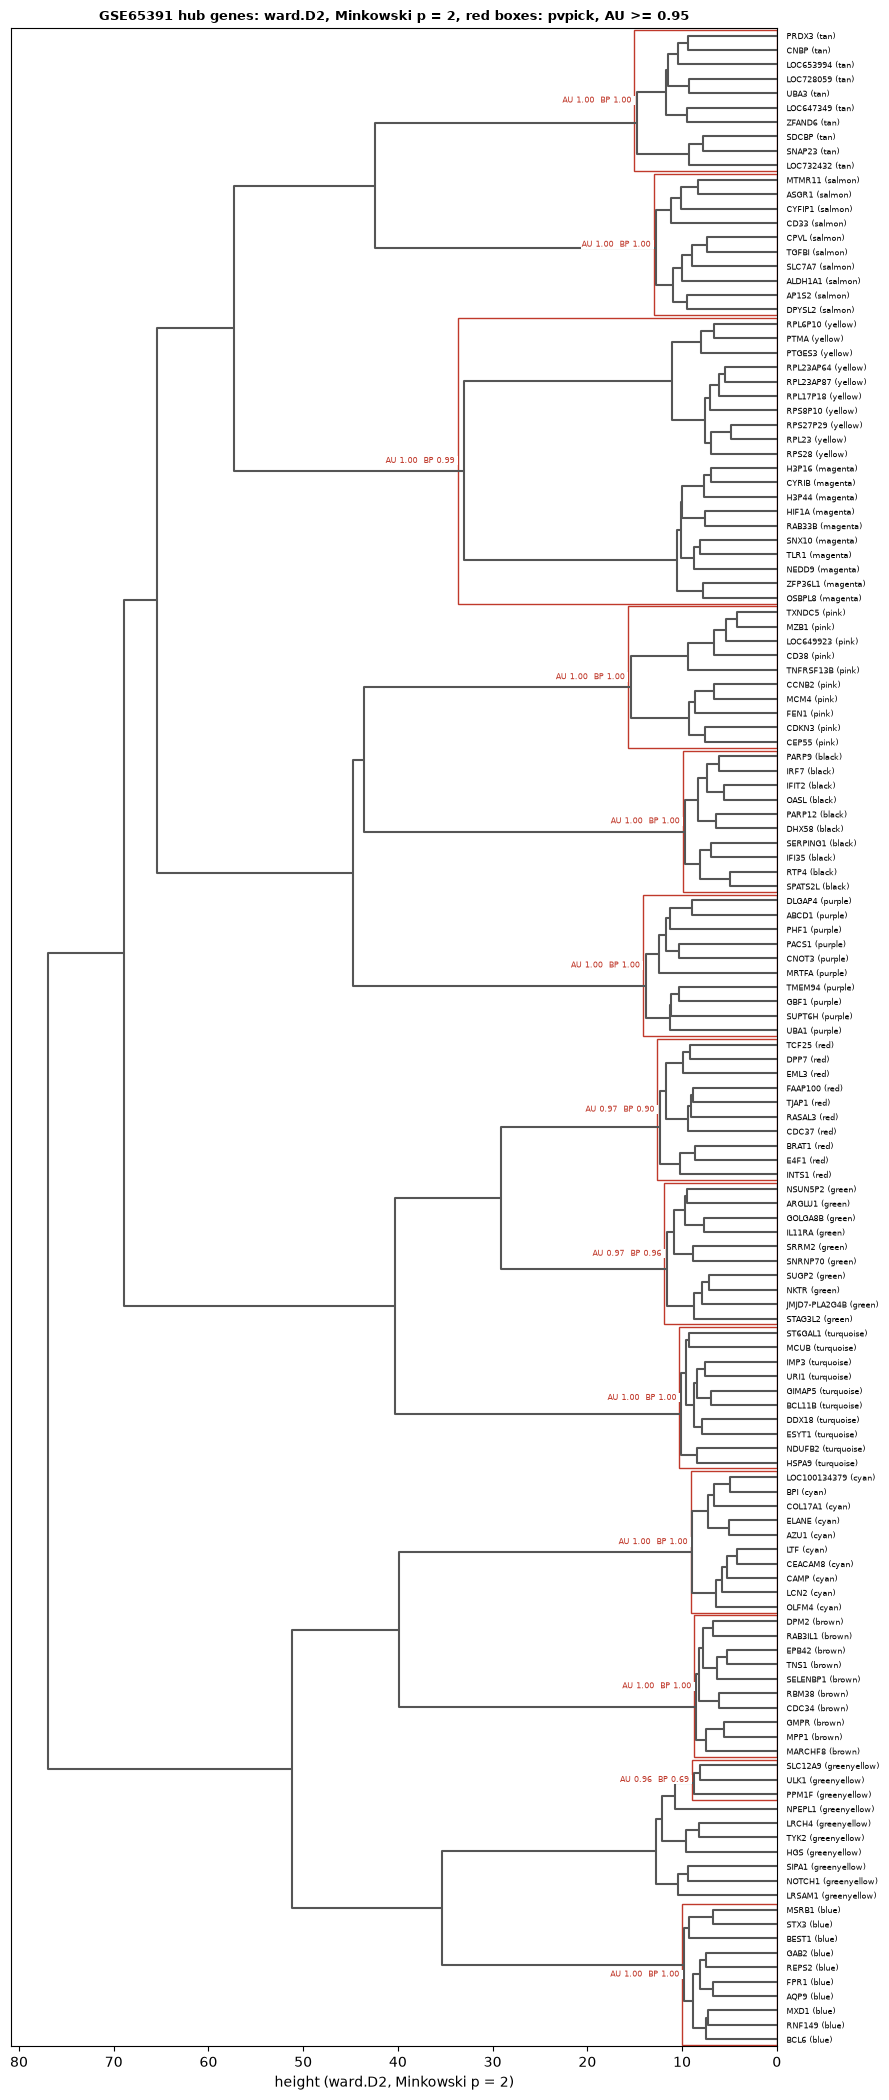

In [5]:
# The pvclust tree with every label shown. Each red box is one pvpick cluster (AU >= 0.95),
# labelled with its AU and BP values (AU: approximately unbiased; BP: ordinary bootstrap).
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import dendrogram as tree

def pv_figure(res, picked, leaf_text, title, path):
    n = len(res.labels)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.14 * n + 1.5)))
    d = tree(res.linkage, labels=[leaf_text[l] for l in res.labels], orientation="left", ax=ax,
             color_threshold=0, above_threshold_color="#555555", leaf_font_size=6)
    pos = {res.labels[j]: 5 + 10 * k for k, j in enumerate(d["leaves"])}
    for e in picked:
        ys = [pos[m] for m in e["members"]]
        h = res.linkage[e["merge_order"] - 1, 2] * 1.02
        ax.add_patch(Rectangle((0, min(ys) - 4), h, max(ys) - min(ys) + 8, fill=False, edgecolor="#C0392B", lw=1))
        ax.text(h, (min(ys) + max(ys)) / 2, f"AU {e['au']:.2f}  BP {e['bp']:.2f} ", color="#C0392B",
                fontsize=6, ha="right", va="center",
                bbox=dict(facecolor="white", edgecolor="none", pad=0.3))
    ax.set_xlabel("height (ward.D2, Minkowski p = 2)")
    ax.set_title(title, fontsize=9, fontweight="bold")
    fig.tight_layout()
    fig.savefig(path, dpi=300)
    plt.show()

leaf_text = {g: f"{g} ({genes[g]})" for g in res.labels}
pv_figure(res, picked, leaf_text, "GSE65391 hub genes: ward.D2, Minkowski p = 2, red boxes: pvpick, AU >= 0.95", FIG / "08c_GSE65391_RNA_array_pvclust_genes.png")

**Explanation**
- `matplotlib` draws the figure (Hunter JD. Matplotlib: a 2D graphics environment. *Comput Sci Eng*
  2007;9:90-95); `scipy.cluster.hierarchy.dendrogram` draws the tree from the linkage matrix (Virtanen P et
  al. SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nat Methods* 2020;17:261-272).
- `pv_figure()` draws the tree on its side with every gene labelled by its module, and a red box around each
  picked cluster, labelled with its AU and BP values.
  - `tree(res.linkage, ..., orientation="left")` draws the tree from SciPy's dendrogram function; `labels`
    gives each leaf its text.
  - `pos` records the vertical position of each leaf; SciPy places leaves 10 units apart, starting at 5.
  - For each picked cluster, `Rectangle(...)` draws the box from the leaves' positions up to the height of the
    branch, and `ax.text(...)` writes AU and BP beside it on a white background.
  - `fig.savefig(path, dpi=300)` saves the figure as a 300 dpi PNG; `plt.show()` shows it in the notebook.
- The last two lines give each gene its label, for example `OASL (black)`, and draw the figure.

## Save

In [6]:
pickle.dump(res, open(ART / "pvclust_genes.pkl", "wb"))

**Explanation**
- `pickle.dump(res, open(file, "wb"))` saves the whole pvclust result to a file, so notebook 08d can reuse
  it for its two-way figure without running pvclust again. `"wb"` means write bytes, as in notebook 00.